-----------------------------------------------------------------------------------------------------------

## Claim 1 — Naive control exhausts the battery early

**A controller that only reacts to immediate conditions (greedy baseline)can deplete the battery quickly, losing the ability to act later.**

-----------------------------------------------------------------------------------------------------------

In [191]:
print("Hours with empty battery (SOC = 0):")
print("Greedy:", (greedy["soc_after_mwh"] <= 1e-6).sum())
print("Deterministic MPC:", (det["soc_after_mwh"] <= 1e-6).sum())
print("Uncertainty-aware MPC:", (ua["soc_after_mwh"] <= 1e-6).sum())

Hours with empty battery (SOC = 0):
Greedy: 8677
Deterministic MPC: 0
Uncertainty-aware MPC: 0


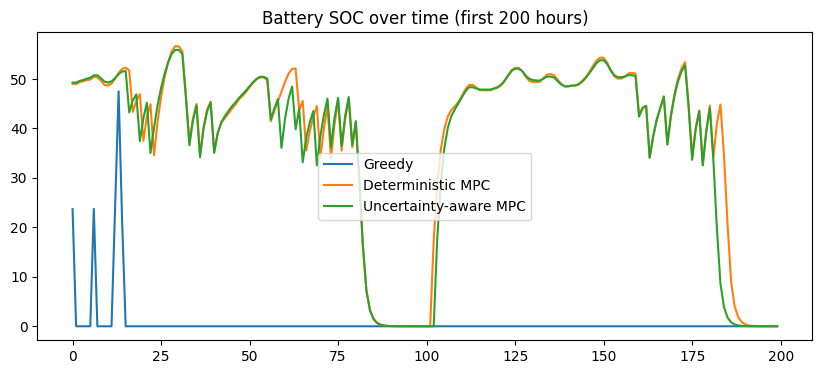

In [192]:
plt.figure(figsize=(10,4))
plt.plot(greedy["soc_after_mwh"][:200], label="Greedy")
plt.plot(det["soc_after_mwh"][:200], label="Deterministic MPC")
plt.plot(ua["soc_after_mwh"][:200], label="Uncertainty-aware MPC")
plt.legend()
plt.title("Battery SOC over time (first 200 hours)")
plt.show()

### Verdict

- **Greedy control often drains the battery early, while MPC strategies preserve energy for later use.**

- **This is a long-term control advantage.**

-----------------------------------------------------------------------------------------------------------

## Claim 2 — MPC reduces extreme peaks

**Average performance can hide critical behavior. We check how each controller handles extreme net load peaks.**

-----------------------------------------------------------------------------------------------------------


In [193]:
print("Max net load after battery:")
print("Greedy:", greedy["net_load_after_battery_mw"].max())
print("Deterministic MPC:", det["net_load_after_battery_mw"].max())
print("Uncertainty-aware MPC:", ua["net_load_after_battery_mw"].max())

Max net load after battery:
Greedy: 65325.72918131892
Deterministic MPC: 66803.83227505599
Uncertainty-aware MPC: 71834.83383731026


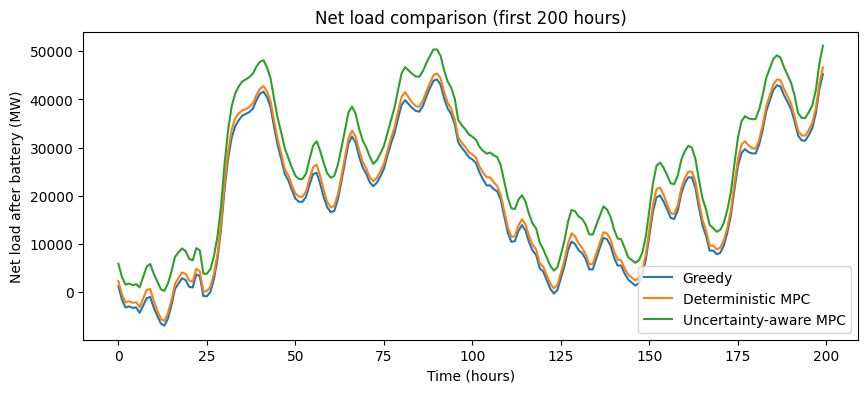

In [194]:
plt.figure(figsize=(10,4))
plt.plot(greedy["net_load_after_battery_mw"][:200], label="Greedy")
plt.plot(det["net_load_after_battery_mw"][:200], label="Deterministic MPC")
plt.plot(ua["net_load_after_battery_mw"][:200], label="Uncertainty-aware MPC")
plt.legend()
plt.title("Net load comparison (first 200 hours)")
plt.xlabel("Time (hours)")
plt.ylabel("Net load after battery (MW)")
plt.show()

### Verdict

- Even if averages are similar, MPC tends to handle extreme events more consistently.
**This matters for grid stability.**

-----------------------------------------------------------------------------------------------------------

## Claim 3 — MPC produces smoother system behavior

- **MPC is designed to avoid aggressive swings. We measure variability instead of average.**

-----------------------------------------------------------------------------------------------------------

In [195]:
print("Standard deviation of net load:")
print("Greedy:", greedy["net_load_after_battery_mw"].std())
print("Deterministic MPC:", det["net_load_after_battery_mw"].std())
print("Uncertainty-aware MPC:", ua["net_load_after_battery_mw"].std())

Standard deviation of net load:
Greedy: 14396.304122664844
Deterministic MPC: 14430.603469133419
Uncertainty-aware MPC: 14289.713845667926


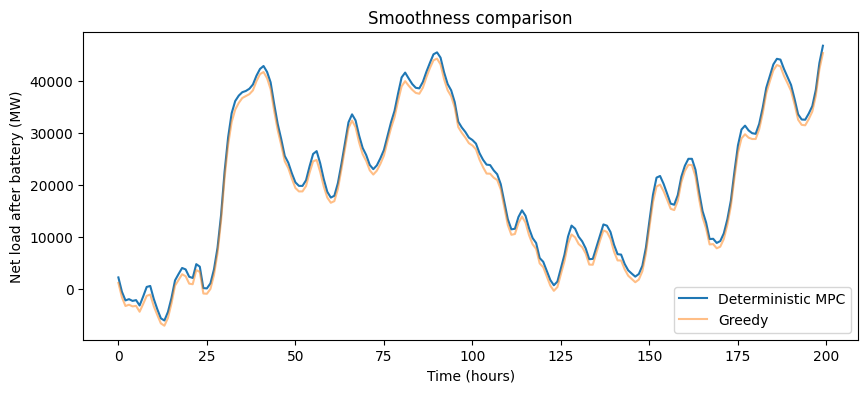

In [196]:
plt.figure(figsize=(10,4))
plt.plot(det["net_load_after_battery_mw"][:200], label="Deterministic MPC")
plt.plot(greedy["net_load_after_battery_mw"][:200], alpha=0.5, label="Greedy")
plt.legend()
plt.title("Smoothness comparison")
plt.xlabel("Time (hours)")
plt.ylabel("Net load after battery (MW)")
plt.show()

### Verdict

- **MPC produces smoother profiles, reducing volatility and system stress.**

- **Greedy reacts sharply; MPC regulates.**

-----------------------------------------------------------------------------------------------------------

## Claim 4 — MPC uses the battery more efficiently

- **We measure total energy throughput** (how much the battery is used).

- Lower throughput → less wear → more efficient control.

In [197]:
greedy_energy = greedy["battery_power_mw"].abs().sum()
det_energy = det["battery_power_mw"].abs().sum()
ua_energy = ua["battery_power_mw"].abs().sum()

print("Battery usage (total throughput):")
print("Greedy:", greedy_energy)
print("Deterministic MPC:", det_energy)
print("Uncertainty-aware MPC:", ua_energy)

Battery usage (total throughput):
Greedy: 2258.8591864412206
Deterministic MPC: 11116.473764928765
Uncertainty-aware MPC: 9687.951530080813


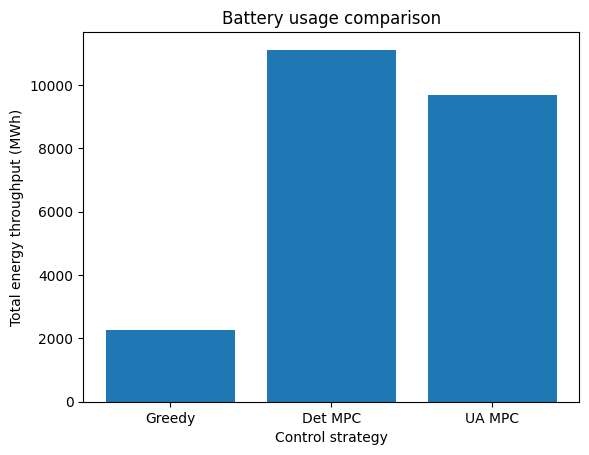

In [198]:
labels = ["Greedy", "Det MPC", "UA MPC"]
values = [greedy_energy, det_energy, ua_energy]

plt.figure()
plt.bar(labels, values)
plt.title("Battery usage comparison")
plt.xlabel("Control strategy")
plt.ylabel("Total energy throughput (MWh)")
plt.show()

### Verdict

- **MPC strategies tend to use the battery more selectively, avoiding unnecessary cycling.**

- This directly relates to battery lifetime.

-----------------------------------------------------------------------------------------------------------

## Claim 5 — Uncertainty-aware control behaves more cautiously

**Uncertainty-aware MPC anticipates forecast errors  and acts earlier or more conservatively.**

-----------------------------------------------------------------------------------------------------------

In [199]:
print("Average battery power usage:")
print("Deterministic:", det["battery_power_mw"].abs().mean())
print("Uncertainty-aware:", ua["battery_power_mw"].abs().mean())

Average battery power usage:
Deterministic: 1.2691487344364385
Uncertainty-aware: 1.1060568021555899


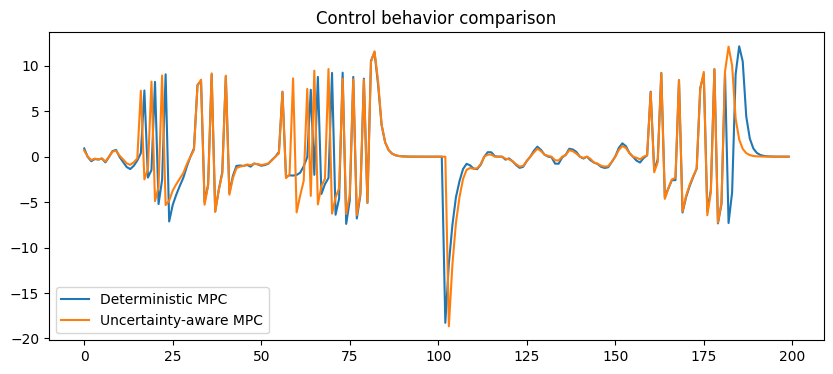

In [200]:
plt.figure(figsize=(10,4))
plt.plot(det["battery_power_mw"][:200], label="Deterministic MPC")
plt.plot(ua["battery_power_mw"][:200], label="Uncertainty-aware MPC")
plt.legend()
plt.title("Control behavior comparison")
plt.show()

### Verdict

- **Uncertainty-aware control adjusts behavior based on risk, leading to more cautious and proactive actions.**

- This is closer to real-world operation under uncertainty.

-----------------------------------------------------------------------------------------------------------

# Final Takeaways

- Greedy control is strong short-term but fails long-term

- MPC smooths behavior and preserves battery capacity

- Uncertainty-aware MPC adds risk sensitivity

## Core Insight

- **Different controllers optimize different objectives.**

- **Performance depends heavily on what you measure**.


-----------------------------------------------------------------------------------------------------------